In this version, we expanded the dataset from the Goldschmidt Tolerance Factor (GTF) iteration. Not all perovskite structures have the ABX3 profile, but the GTF relies on this ABX3 structure. To ensure our model can train on a proper sample size, we are moving to more general structure restrictions, and have removed the GTF from our features.

In the utils.py we added a is_plausible_perovskite function. We want to ensure it has one or more halides, one metal, and no more than 4 entries in the formula. This allows for some variance, but we keep ourselves restructed to single B-site perovskites and will implement double perovskite generality in a later iteration.

We also introduce spacegroup number as a structural feature, encoding crystallographic symmetry information that compositional features like MAGPIE cannot capture, as structural distortions from ideal cubic symmetry are themselves indicators of stability.

Finally, we made adjustments to the minimum sample leaf size as well as the max depth. We set values that help reduce our overfitting. Prior to this adjustment, our R^2 for the test was around a 0.39 but for the train dataset the R^2 was near 0.93. In simple terms, the model was memorizing the training data in ways that did not generalize to the test data. After making our changes, the model has a test R^2 of 0.52 and a train R^2 of 0.79. Though an improvement, some overfitting is still present and we will address this in the next iteration, V5. 



In [1]:
from mp_api.client import MPRester
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
load_dotenv()
MY_API_KEY = os.getenv("MP_API_KEY")

In [2]:
# Import helper functions and global vars from utils
from utils import query_materials_project, ionic_radii, compute_tolerance_factor, halides, metals

In [3]:
halide_families = [[metal, halide] for metal in metals for halide in halides]
df =  query_materials_project(MY_API_KEY, halide_families)

print(f"Found {len(df)} materials after cleaning")
print(df.head())
print("\nMissing values per column:")
print(df.isnull().sum())

Retrieving SummaryDoc documents:   0%|          | 0/19 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/16 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/25 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/38 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/77 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/50 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/89 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/79 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/62 [00:00<?, ?it/s]

Found 305 materials after cleaning
   formula  band_gap  energy_above_hull  formation_energy       volume  \
0  RbGeIO6    2.4456           0.000000         -1.520279   147.817781   
3  Ge2S3I2    2.2528           0.000000         -0.645927  1114.144058   
6   CuGeI3    0.6193           0.254986         -0.239377   168.737259   
7   CsGeI3    0.9905           0.000000         -1.069609   225.068117   
8   TlGeI3    1.9161           0.016987         -0.686466   768.288709   

    density  nsites  spacegroup_number  
0  4.280133       9                149  
3  2.952718      28                147  
6  5.086794       5                  8  
7  4.325383       5                160  
8  5.686391      20                 62  

Missing values per column:
formula              0
band_gap             0
energy_above_hull    0
formation_energy     0
volume               0
density              0
nsites               0
spacegroup_number    0
dtype: int64


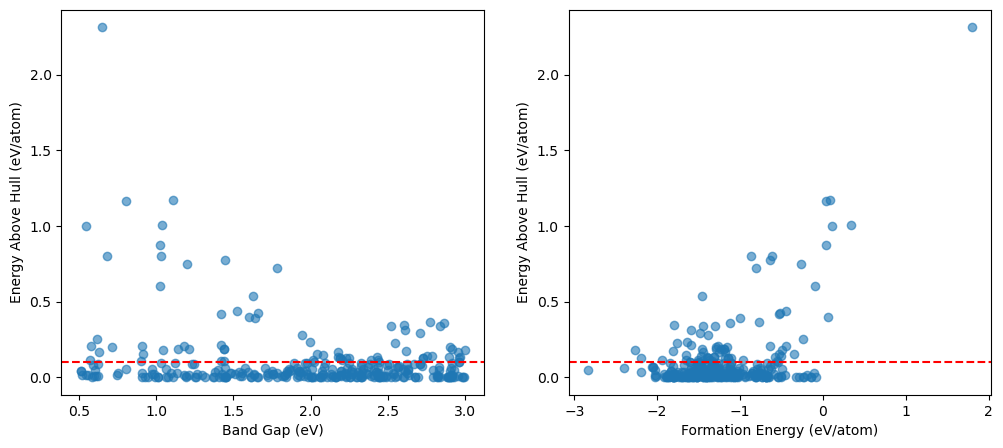

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Plotting Band Gap vs Stability (energy above hull)
axes[0].scatter(df["band_gap"], df["energy_above_hull"], alpha = 0.6)
axes[0].axhline(y = 0.1, color = "r", linestyle = "--")
axes[0].set_xlabel("Band Gap (eV)")
axes[0].set_ylabel("Energy Above Hull (eV/atom)")

# Plotting Formation energy vs. Stability (energy above hull)
axes[1].scatter(df["formation_energy"], df["energy_above_hull"], alpha= 0.6)
axes[1].axhline(y = 0.1, color = "r", linestyle = "--")
axes[1].set_xlabel("Formation Energy (eV/atom)")
axes[1].set_ylabel("Energy Above Hull (eV/atom)")

plt.show()

In [5]:
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition

str_to_comp = StrToComposition()
df = str_to_comp.featurize_dataframe(df, "formula", ignore_errors=True)
ep_featurizer = ElementProperty.from_preset("magpie")
df = ep_featurizer.featurize_dataframe(df, col_id = "composition", ignore_errors=True)

StrToComposition:   0%|          | 0/305 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/305 [00:00<?, ?it/s]

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Cleaning non-numeric features from the dataframe as the model cannot use them
exclude_cols = ["formula", "composition", "energy_above_hull", "band_gap",
"formation_energy", "volume", "density", "nsites"]
feature_cols = [col for col in df.columns if col not in exclude_cols]
df_clean = df.dropna(subset = feature_cols  + ["energy_above_hull"])

X = df_clean[feature_cols]
y = df_clean["energy_above_hull"]
print(f"Post cleaning and featurization, we are now training on {X.shape[0]} materials with {X.shape[1]} features")

Post cleaning and featurization, we are now training on 305 materials with 133 features


In [7]:
# split our data into the test and training sets using 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Display number of samples in training and testing sets
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# Train the model: Here we create 100 different trees for the random forest, and set a random state for reproducability
# We also set max_depth and min_samples_leaf to address overfitting, which can be a common issue with random forests if the trees are allowed to grow too deep.
rf = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_leaf=3, random_state=42)

rf.fit(X_train, y_train)

# Evaluate
# Using the trained model, we take our testing data, X_test, and predict the energy above hull values, y_pred
# We then compare these predicted values against the actual test values, y_test, and claculate r^2 values and mean absolute error.
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Finally, we print out our evaluation of the model's accuracy 
print(f"Mean Absolute Error: {mae:.4f} eV/atom")
print(f"R² Score: {r2:.4f}")

print(f"R² Score (Training): {r2_score(y_train, rf.predict(X_train))
:.4f}")

Training set: 244 samples
Testing set: 61 samples
Mean Absolute Error: 0.0618 eV/atom
R² Score: 0.6393
R² Score (Training): 0.7980


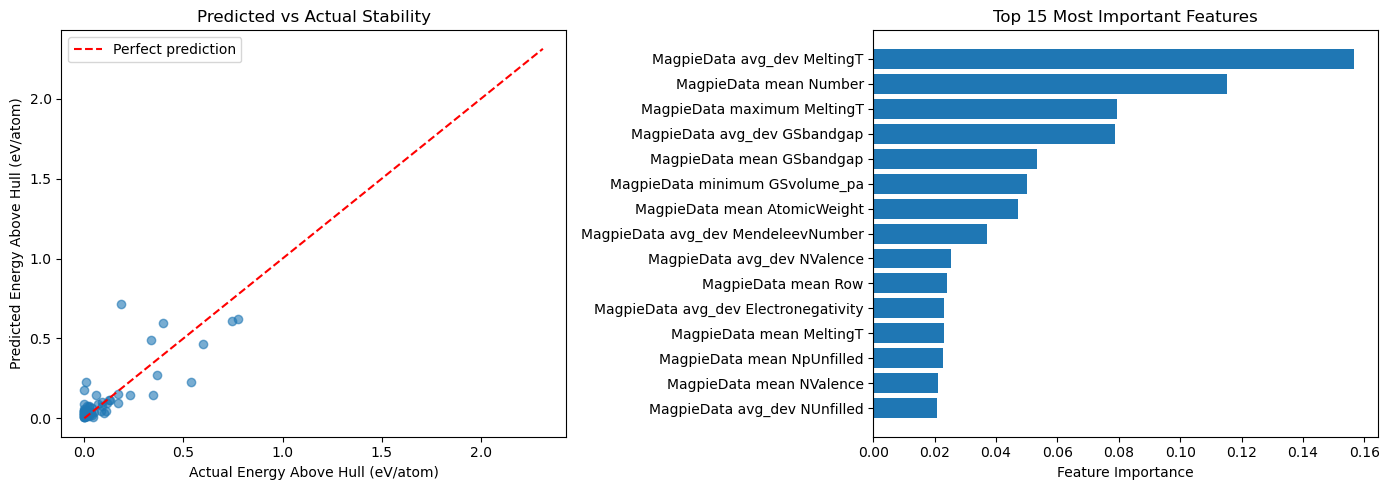

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.6)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel("Actual Energy Above Hull (eV/atom)")
axes[0].set_ylabel("Predicted Energy Above Hull (eV/atom)")
axes[0].set_title("Predicted vs Actual Stability")
axes[0].legend()

# Top 15 most important features
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top_features = importances.sort_values(ascending=False).head(15)

axes[1].barh(top_features.index[::-1], top_features.values[::-1])
axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Top 15 Most Important Features")

plt.tight_layout()
plt.show()